<a href="https://colab.research.google.com/github/christianasmussenb/AgentIQ/blob/develop/cxr-foundation/CXR_Foundation_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/Google-Health/imaging-research/blob/master/cxr-foundation/CXR_Foundation_Demo.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/Google-Health/imaging-research/blob/master/cxr-foundation/CXR_Foundation_Demo.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>


# CXR Foundation Demo

This notebook demonstrates the richness of information contained in embeddings, generated from full Chest X-Ray images. The contents include how to:

- Download DICOM images and labels from the open-access NIH ChestX-ray14 dataset
- Use the CXR Foundation API to generate image embeddings from the DICOMs
- Train a simple neural network (WITHOUT needing GPU) to detect a medical finding in the embeddings

## Prerequisites

You must have access to use the CXR Foundation API. See the project's [README](https://github.com/Google-Health/imaging-research/blob/master/cxr-foundation/README.md) for details.

# Installation

Install the CXR Foundation package

In [1]:
# Notebook specific dependencies
!pip install matplotlib tf-models-official==2.14.0 google-cloud-storage

!git clone https://github.com/Google-Health/imaging-research.git
!pip install imaging-research/cxr-foundation/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

**IMPORTANT**: If you are using Colab, you must restart the runtime after installing new packages.

NOTE: There will be some ERROR messages due to the protobuf library - this is normal.

# Authenticate to Access Data

The following cell is for Colab only. If running elsewhere, authenticate with the [gcloud CLI](https://cloud.google.com/sdk/gcloud/reference/auth/login).

In [1]:
USE_SERVICE_ACCOUNT = False #@param {type: 'boolean'}

from google.colab import auth

# Authenticate user for access.
if USE_SERVICE_ACCOUNT:
  # There will be a prompt below asking you to upload your service account key as a JSON file.
  auth.authenticate_service_account()
else:
  # There will be a popup asking you to sign in with your user and approve access.
  auth.authenticate_user()

# Download Data

The NIH ChestX-ray14 dataset, consists of over 100,000 de-identified images of chest x-rays, with fourteen common disease labels, text-mined from the text radiological reports via NLP techniques. The dataset is available on the NIH [download site](https://nihcc.app.box.com/v/ChestXray-NIHCC) and on [Google Cloud](https://cloud.google.com/healthcare-api/docs/resources/public-datasets/nih-chest).

The CXR Foundation Demo GCS [bucket](https://console.cloud.google.com/storage/browser/cxr-foundation-demo) contains a subset of the data. We will download the dataset's labels file and some DICOM images below. This might take ~10 minutes or so depending on your connection speed.

In [2]:
import io
import os

from google.cloud import storage
import pandas as pd

# Make a directory to download the data
if not os.path.exists('data'):
  os.mkdir('data')

# Initialize the GCS storage client
storage_client = storage.Client()
bucket = storage_client.get_bucket('cxr-foundation-demo')

# Download and inspect the labels file.
# There is a column for each of several findings, which indicate whether or not
# the condition is present in the image file.
full_labels_df = pd.read_csv(io.BytesIO(bucket.blob('cxr14/labels.csv').download_as_string()))
# DICOM file paths on the data bucket
full_labels_df['remote_dicom_file'] = full_labels_df['image_id'].apply(lambda x: os.path.join('cxr14', 'inputs', x.replace('.png', '.dcm')))
display(full_labels_df.head())

,image_id,patient_id,case_id,split,AIRSPACE_OPACITY,FRACTURE,PNEUMOTHORAX,CONSOLIDATION,EFFUSION,PULMONARY_EDEMA,ATELECTASIS,CARDIOMEGALY,remote_dicom_file
0,00004850_004.png,4850,4,train,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,cxr14/inputs/00004850_004.dcm
1,00007962_001.png,7962,1,train,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,cxr14/inputs/00007962_001.dcm
2,00008682_000.png,8682,0,train,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,cxr14/inputs/00008682_000.dcm
3,00018739_006.png,18739,6,train,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,cxr14/inputs/00018739_006.dcm
4,00019255_000.png,19255,0,train,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,cxr14/inputs/00019255_000.dcm


Download the DICOM files, organized by the AIRSPACE_OPACITY label.

Download 100 of each case: positive and negative

In [3]:
DIAGNOSIS = 'AIRSPACE_OPACITY' #@param {type: 'string'}
MAX_CASES_PER_CATEGORY = 100 #@param {type: 'integer'}
DICOM_DIR = './data/inputs' #@param {type: 'string'}
EMBEDDINGS_DIR = './data/outputs' #@param {type: 'string'}

# Labels df of relevant files
df_labels = pd.concat((full_labels_df[full_labels_df[DIAGNOSIS]==0][:MAX_CASES_PER_CATEGORY],
                      full_labels_df[full_labels_df[DIAGNOSIS]==1][:MAX_CASES_PER_CATEGORY]), ignore_index=True)
df_labels = df_labels[["remote_dicom_file", DIAGNOSIS]]

# Path for downloaded DICOMs
df_labels["dicom_file"] = df_labels["remote_dicom_file"].apply(
    lambda x: os.path.join(DICOM_DIR, os.path.basename(x)))
# Path for generated embeddings
df_labels["embedding_file"] =  df_labels['dicom_file'].apply(
    lambda x: os.path.join(EMBEDDINGS_DIR, os.path.basename(x).replace(".dcm", ".tfrecord")))

df_labels

,remote_dicom_file,AIRSPACE_OPACITY,dicom_file,embedding_file
0,cxr14/inputs/00026260_000.dcm,0.0,./data/inputs/00026260_000.dcm,./data/outputs/00026260_000.tfrecord
1,cxr14/inputs/00026587_000.dcm,0.0,./data/inputs/00026587_000.dcm,./data/outputs/00026587_000.tfrecord
2,cxr14/inputs/00022115_000.dcm,0.0,./data/inputs/00022115_000.dcm,./data/outputs/00022115_000.tfrecord
3,cxr14/inputs/00008972_002.dcm,0.0,./data/inputs/00008972_002.dcm,./data/outputs/00008972_002.tfrecord
4,cxr14/inputs/00027108_012.dcm,0.0,./data/inputs/00027108_012.dcm,./data/outputs/00027108_012.tfrecord
...,...,...,...,...
195,cxr14/inputs/00013613_020.dcm,1.0,./data/inputs/00013613_020.dcm,./data/outputs/00013613_020.tfrecord
196,cxr14/inputs/00013894_033.dcm,1.0,./data/inputs/00013894_033.dcm,./data/outputs/00013894_033.tfrecord
197,cxr14/inputs/00018749_000.dcm,1.0,./data/inputs/00018749_000.dcm,./data/outputs/00018749_000.tfrecord
198,cxr14/inputs/00018329_008.dcm,1.0,./data/inputs/00018329_008.dcm,./data/outputs/00018329_008.tfrecord


In [4]:
if not os.path.exists(DICOM_DIR):
    os.makedirs(DICOM_DIR)

for _, row in df_labels.iterrows():
  blob = bucket.blob(row["remote_dicom_file"])
  if blob.exists():
    blob.download_to_filename(row["dicom_file"])
print("Finished downloading DICOM files!")

Finished downloading DICOM files!


# Util functions and imports

In [5]:
import io
import pydicom
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from cxr_foundation import constants
from cxr_foundation import example_generator_lib

def show_dicom(adicom):
  """Shows the DICOM in a format as passed to CXR Foundation."""
  png_image_data = example.features.feature[
      constants.IMAGE_KEY].bytes_list.value[:][0]
  image = Image.open(io.BytesIO(png_image_data))
  figure_size=7
  f, axarr = plt.subplots(1, 1, figsize = (figure_size, figure_size))
  axarr.imshow(image, cmap='gray')
  axarr.axis('off')
  plt.show()

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.6.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.11.15
aiosignal                             1.3.2
alabaster                             1.0.0
albucore                              0.0.23
albumentations                        2.0.5
ale-py                                0.10.2
altair                                5.5.0
annotated-types                       0.7.0
anyio                                 4.9.0
argon2-cffi                           23.1.0
argon2-cffi-bindings                  21.2.0
array_record                          0.7.1
arviz                                 0.21.0
astropy                               7.0.1
astropy-iers-data                     0.2025.4.21.0.37.6
astunparse                            1.6.3
atpublic                              5.1

# Generate Embeddings

**IMPORTANT:** You must have access to use the CXR Foundation API. See the project's [README](https://github.com/Google-Health/imaging-research/blob/master/cxr-foundation/README.md) for details.

Generate embeddings (think of them as compressed images) from the downloaded DICOMs. This may take ~15 minutes depending on the load on the server and your connection speed.

*There may be some warnings about "Could not load dynamic library" and or "No project ID could be determined," but these can be safely ignored.*

## Storage Format

The cxr-foundation library supports storing generated values in both .npz and .tfrecord format.

The following cells demonstrate how to do both. The subsequent model training section will only use the .tfrecord files.

## Embedding Version

We support the following three embedding versions:
- cxr_foundation: the original CXR foundation embedding
- elixr: the raw image embedding from the Q-former output in ELIXR (https://arxiv.org/abs/2308.01317), can be used for data-efficient classification (same as CXR foundation embedding)
- elixr_img_contrastive: the text-aligned image embedding from the Q-former output in ELIXR (https://arxiv.org/abs/2308.01317), can be used for image retrieval. Refer to "Image Retrieval Demo" section in this colab for example usage.


## Selection between embedding versions

In [20]:
from cxr_foundation.inference import ModelVersion
import shutil

EMBEDDING_VERSION = 'elixr_img_contrastive' #@param ['elixr', 'cxr_foundation', 'elixr_img_contrastive']
if EMBEDDING_VERSION == 'cxr_foundation':
  MODEL_VERSION = ModelVersion.V1
  TOKEN_NUM = 1
  EMBEDDINGS_SIZE = 1376
elif EMBEDDING_VERSION == 'elixr':
  MODEL_VERSION = ModelVersion.V2
  TOKEN_NUM = 32
  EMBEDDINGS_SIZE = 768
elif EMBEDDING_VERSION == 'elixr_img_contrastive':
  MODEL_VERSION = ModelVersion.V2_CONTRASTIVE
  TOKEN_NUM = 32
  EMBEDDINGS_SIZE = 128
if not os.path.exists(EMBEDDINGS_DIR):
  os.makedirs(EMBEDDINGS_DIR)
else:
  # Empty embedding dir to avoid caching when switching embedding versions
  shutil.rmtree(EMBEDDINGS_DIR)
  os.makedirs(EMBEDDINGS_DIR)

## Optional (test run for a few cases)

### Check DICOM files to make sure image data appears valid.

There are total of 200 images. We will sample 2 to display.
Image 77


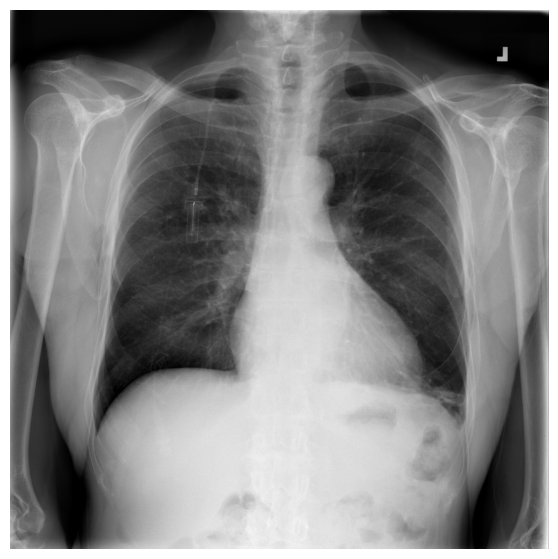

Image 133


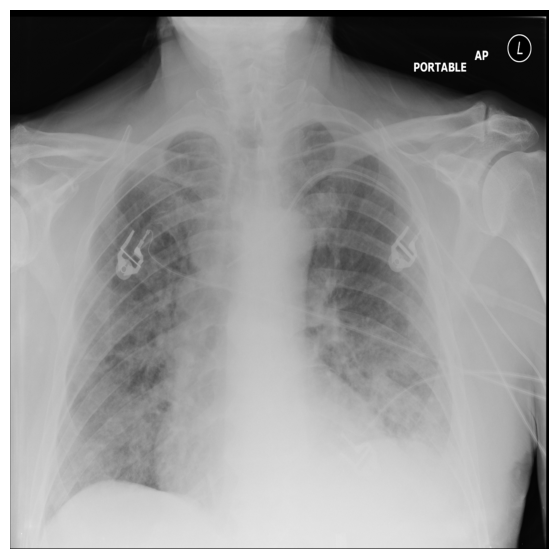

In [21]:
import random
max_index = len(df_labels["dicom_file"].values)
file_to_visualize = 2
print('There are total of %s images. We will sample %d to display.' % (max_index, file_to_visualize))
list_of_images = random.sample(range(0, max_index-1), file_to_visualize)

for image_idx in list_of_images:
  dicom = pydicom.dcmread(df_labels["dicom_file"].values[image_idx])
  example = example_generator_lib.dicom_to_tfexample(dicom)
  print('Image %d' % image_idx)
  show_dicom(example)

### Try inference on 5 cases

In [22]:
import logging

from cxr_foundation.inference import generate_embeddings, InputFileType, OutputFileType, ModelVersion


logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Generate and store a few embeddings in .npz format
generate_embeddings(input_files=df_labels["dicom_file"].values[:5], output_dir=EMBEDDINGS_DIR,
    input_type=InputFileType.DICOM, output_type=OutputFileType.NPZ, model_version=MODEL_VERSION)

INFO:root:Successfully generated './data/outputs/00026260_000.npz'
INFO:root:Successfully generated './data/outputs/00026587_000.npz'
INFO:root:Successfully generated './data/outputs/00022115_000.npz'
INFO:root:Successfully generated './data/outputs/00008972_002.npz'
INFO:root:Successfully generated './data/outputs/00027108_012.npz'


In [23]:
from cxr_foundation import embeddings_data

# Read the data from a generated .npz embeddings file.
filename = df_labels["embedding_file"][0].replace("tfrecord", "npz")
values = embeddings_data.read_npz_values(filename)

print(values.shape)

# NOTE: The rest of the notebook will use the .tfrecord data

(4096,)


## Generate all embeddings

In [24]:
# Generate all the embeddings in .tfrecord format
generate_embeddings(input_files=df_labels["dicom_file"].values, output_dir=EMBEDDINGS_DIR,
    input_type=InputFileType.DICOM, output_type=OutputFileType.TFRECORD, model_version=MODEL_VERSION)

INFO:root:Successfully generated './data/outputs/00026260_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00026587_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00022115_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00008972_002.tfrecord'
INFO:root:Successfully generated './data/outputs/00027108_012.tfrecord'
INFO:root:Successfully generated './data/outputs/00005216_010.tfrecord'
INFO:root:Successfully generated './data/outputs/00022852_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00018808_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00028987_001.tfrecord'
INFO:root:Successfully generated './data/outputs/00006582_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00020339_004.tfrecord'
INFO:root:Successfully generated './data/outputs/00016919_010.tfrecord'
INFO:root:Successfully generated './data/outputs/00025232_000.tfrecord'
INFO:root:Successfully generated './data/outputs/00000857_008.tf

In [25]:
# Inspect a tfrecord embedding file. A single file is only several kbs.
filename = df_labels["embedding_file"][0]

# Read the tf.train.Example object from the first tfrecord file
example = embeddings_data.read_tfrecord_example(filename)
print(example)

# If you don't care about the structure of the .tfrecord file, and/or if
# you don't use Tensorflow, you can use the following function to read
# the values directly into a numpy array.
values = embeddings_data.read_tfrecord_values(filename)
print(values.shape)

features {
  feature {
    key: "embedding"
    value {
      float_list {
        value: -0.135687307
        value: -0.0770337805
        value: -0.098491028
        value: 0.122283496
        value: -0.141499043
        value: -0.026066808
        value: -0.0024470184
        value: 0.0623841323
        value: 0.0313442796
        value: -0.109044679
        value: -0.124096796
        value: -0.0952348113
        value: 0.0378178284
        value: -0.0476528965
        value: -0.0425596461
        value: -0.0705232695
        value: -0.0679286346
        value: 0.0403782949
        value: -0.110237531
        value: -0.110515393
        value: 0.0689218268
        value: -0.0639629886
        value: -0.125556126
        value: 0.0419284105
        value: 0.0164569542
        value: -0.073598735
        value: 0.0873272046
        value: -0.0651375651
        value: 0.163559407
        value: -0.00311121391
        value: -0.113329478
        value: 0.0238016937
        value: -0.10

# Data Efficient Classification Demo

## Prepare Data for Model Training

Separate into training, validation, and testing sets.

In [26]:
from sklearn.model_selection import train_test_split


df_train, df_validate = train_test_split(df_labels, test_size=0.1)

## Train A Model

Finally, we can train a model using the embeddings! With a simple feed-forward neural network, it should take < 5 minutes to train 100 epochs! No GPU required.

In [27]:
import tensorflow as tf
import tensorflow_models as tfm


def create_model(heads,
                 # token_num=1 for original CXR foundation embedding
                 # token_num=32 for ELIXR embedding
                 token_num=1,
                 embeddings_size=1376,
                 learning_rate=0.1,
                 end_lr_factor=1.0,
                 dropout=0.0,
                 decay_steps=1000,
                 loss_weights=None,
                 hidden_layer_sizes=[512, 256],
                 weight_decay=0.0,
                 seed=None) -> tf.keras.Model:
  """
  Creates linear probe or multilayer perceptron using LARS + cosine decay.


  """
  inputs = tf.keras.Input(shape=(token_num * embeddings_size,))
  inputs_reshape = tf.keras.layers.Reshape((token_num, embeddings_size))(inputs)
  inputs_pooled = tf.keras.layers.GlobalAveragePooling1D(data_format='channels_last')(inputs_reshape)
  hidden = inputs_pooled
  # If no hidden_layer_sizes are provided, model will be a linear probe.
  for size in hidden_layer_sizes:
    hidden = tf.keras.layers.Dense(
        size,
        activation='relu',
        kernel_initializer=tf.keras.initializers.HeUniform(seed=seed),
        kernel_regularizer=tf.keras.regularizers.l2(l2=weight_decay),
        bias_regularizer=tf.keras.regularizers.l2(l2=weight_decay))(
            hidden)
    hidden = tf.keras.layers.BatchNormalization()(hidden)
    hidden = tf.keras.layers.Dropout(dropout, seed=seed)(hidden)
  output = tf.keras.layers.Dense(
      units=len(heads),
      activation='sigmoid',
      kernel_initializer=tf.keras.initializers.HeUniform(seed=seed))(
          hidden)

  outputs = {}
  for i, head in enumerate(heads):
    outputs[head] = tf.keras.layers.Lambda(
        lambda x: x[..., i:i + 1], name=head.lower())(
            output)

  model = tf.keras.Model(inputs, outputs)
  learning_rate_fn = tf.keras.experimental.CosineDecay(
      tf.cast(learning_rate, tf.float32),
      tf.cast(decay_steps, tf.float32),
      alpha=tf.cast(end_lr_factor, tf.float32))
  model.compile(
      optimizer=tfm.optimization.lars.LARS(
          learning_rate=learning_rate_fn),
      loss=dict([(head, 'binary_crossentropy') for head in heads]),
      loss_weights=loss_weights or dict([(head, 1.) for head in heads]),
      weighted_metrics=[
        tf.keras.metrics.FalsePositives(),
        tf.keras.metrics.FalseNegatives(),
        tf.keras.metrics.TruePositives(),
        tf.keras.metrics.TrueNegatives(),
        tf.keras.metrics.AUC(),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr')])
  return model

In [28]:
# Create training and validation Datasets
training_data = embeddings_data.get_dataset(
    filenames=df_train["embedding_file"].values,
    labels=df_train[DIAGNOSIS].values,
    embeddings_size=TOKEN_NUM * EMBEDDINGS_SIZE)


validation_data = embeddings_data.get_dataset(
    filenames=df_validate["embedding_file"].values,
    labels=df_validate[DIAGNOSIS].values,
    embeddings_size=TOKEN_NUM * EMBEDDINGS_SIZE)

# Create and train the model
model = create_model(
    [DIAGNOSIS],
    token_num=TOKEN_NUM,
    embeddings_size = EMBEDDINGS_SIZE,
)

model.fit(
    x=training_data.batch(512).prefetch(tf.data.AUTOTUNE).cache(),
    validation_data=validation_data.batch(1).cache(),
    epochs=100,
)

Epoch 1/100
1/1 [==============================] - 4s 4s/step - loss: 0.8258 - false_positives_1: 43.0000 - false_negatives_1: 41.0000 - true_positives_1: 47.0000 - true_negatives_1: 49.0000 - auc_1: 0.5464 - auc_pr: 0.5436 - val_loss: 0.6863 - val_false_positives_1: 1.0000 - val_false_negatives_1: 7.0000 - val_true_positives_1: 5.0000 - val_true_negatives_1: 7.0000 - val_auc_1: 0.7500 - val_auc_pr: 0.8184
Epoch 2/100
1/1 [==============================] - 0s 111ms/step - loss: 0.5425 - false_positives_1: 23.0000 - false_negatives_1: 20.0000 - true_positives_1: 68.0000 - true_negatives_1: 69.0000 - auc_1: 0.8109 - auc_pr: 0.7552 - val_loss: 0.6798 - val_false_positives_1: 0.0000e+00 - val_false_negatives_1: 9.0000 - val_true_positives_1: 3.0000 - val_true_negatives_1: 8.0000 - val_auc_1: 0.9115 - val_auc_pr: 0.9429
Epoch 3/100
1/1 [==============================] - 0s 83ms/step - loss: 0.4017 - false_positives_1: 20.0000 - false_negatives_1: 10.0000 - true_positives_1: 78.0000 - true_n

In [29]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 4096)]            0         
                                                                 
 reshape_1 (Reshape)         (None, 32, 128)           0         
                                                                 
 global_average_pooling1d_1  (None, 128)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_3 (Dense)             (None, 512)               66048     
                                                                 
 batch_normalization_2 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_2 (Dropout)         (None, 512)               0   

## Examine metrics

In [30]:
import sklearn
import matplotlib.pyplot as plt


def plot_curve(x, y, auc, x_label=None, y_label=None, label=None):
  fig = plt.figure(figsize=(10, 10))
  plt.plot(x, y, label=f'{label} (AUC: %.3f)' % auc, color='black')
  plt.legend(loc='lower right', fontsize=18)
  plt.xlim([-0.01, 1.01])
  plt.ylim([-0.01, 1.01])
  if x_label:
    plt.xlabel(x_label, fontsize=24)
  if y_label:
    plt.ylabel(y_label, fontsize=24)
  plt.xticks(fontsize=12)
  plt.yticks(fontsize=12)
  plt.grid(visible=True)

In [31]:
rows = []
for embeddings, label in validation_data.batch(1):
  row = {
      f'{DIAGNOSIS}_prediction': model(embeddings)[DIAGNOSIS].numpy().flatten()[0],
      f'{DIAGNOSIS}_value': label.numpy().flatten()[0]
  }
  rows.append(row)
eval_df = pd.DataFrame(rows)

In [18]:
eval_df.head()

,AIRSPACE_OPACITY_prediction,AIRSPACE_OPACITY_value
0,0.046464,0.0
1,0.000086,0.0
2,0.999259,1.0
3,0.999943,1.0
4,0.999801,1.0


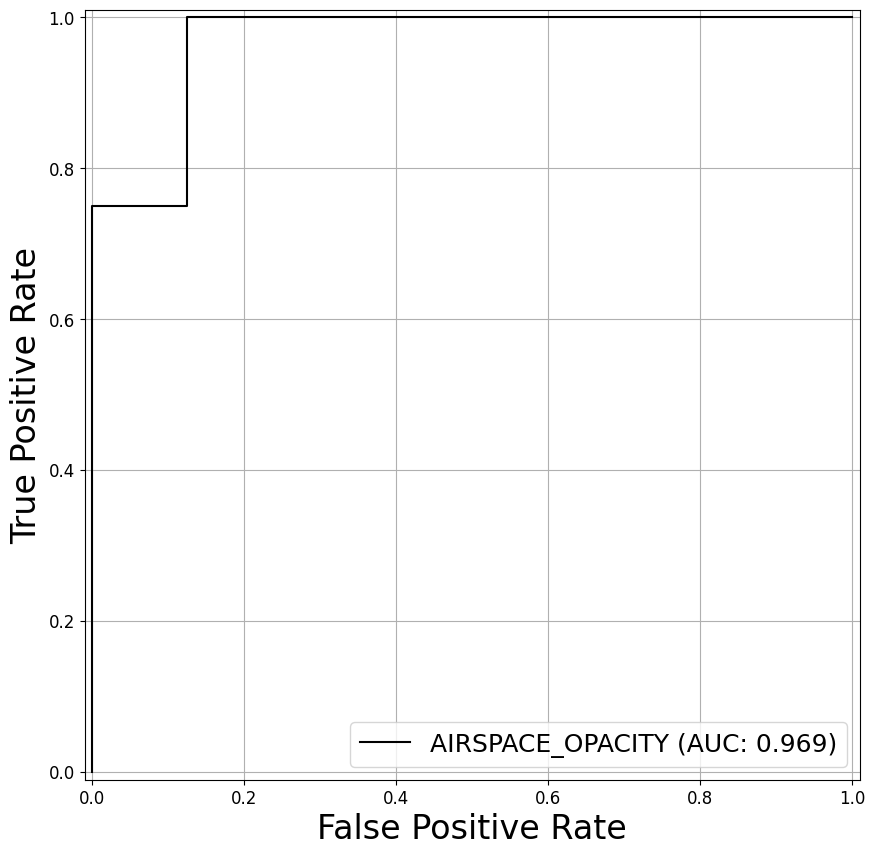

In [32]:
%matplotlib inline
labels = eval_df[f'{DIAGNOSIS}_value'].values
predictions = eval_df[f'{DIAGNOSIS}_prediction'].values
false_positive_rate, true_positive_rate, thresholds = sklearn.metrics.roc_curve(
    labels,
    predictions,
    drop_intermediate=False)
auc = sklearn.metrics.roc_auc_score(labels, predictions)
plot_curve(false_positive_rate, true_positive_rate, auc, x_label='False Positive Rate', y_label='True Positive Rate', label=DIAGNOSIS)

# Image Retrieval Demo

In [33]:
if EMBEDDING_VERSION != 'elixr_img_contrastive':
  raise ValueError(
      'elixr_img_contrastive embedding is required for image retrieval demo.'
  )

In [34]:
TEXT_QUERY = 'Airspace opacity' #@param {type: "string"}

In [35]:
if TEXT_QUERY != 'Airspace opacity':
  raise ValueError(
      'Since the pool of image is from the above 200 airspace opacity sampling,'
      ' the whole image pool might not contain any relevant images other than '
      'airspace opacity, but feel free to explore and run the cells in the '
      'following sections.'
  )

In [36]:
from cxr_foundation.inference import generate_elixr_text_embeddings

txt_emb = generate_elixr_text_embeddings(TEXT_QUERY)
print('text embedding shape:', txt_emb.shape)

INFO:absl:Using /tmp/tfhub_modules to cache modules.
INFO:absl:Downloading TF-Hub Module 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'.
INFO:absl:Downloaded https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3, Total size: 1.96MB
INFO:absl:Downloaded TF-Hub Module 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'.
INFO:absl:Fingerprint not found. Saved model loading will continue.


text embedding shape: (128,)


## Compute image-text similarity and display the top 5 images.

In [37]:
def compute_image_text_similarity(image_emb, txt_emb):
  image_emb = np.reshape(image_emb, (32, 128))
  max_similarity = -1.0
  for i in range(32):
    # cosine similarity
    similarity = np.dot(image_emb[i], txt_emb)/(np.linalg.norm(image_emb[i]) * np.linalg.norm(txt_emb))
    if similarity > max_similarity:
      max_similarity = similarity
  return max_similarity

sim_df_key = []
sim_df_value = []

for _, row in df_labels.iterrows():
  filename = row["embedding_file"]
  values = embeddings_data.read_tfrecord_values(filename)
  similarity = compute_image_text_similarity(values, txt_emb)
  sim_df_key.append(row["remote_dicom_file"])
  sim_df_value.append(similarity)

similarity_df = pd.DataFrame({'remote_dicom_file': sim_df_key, 'similarity': sim_df_value})
similarity_df = similarity_df.merge(df_labels, on='remote_dicom_file')
similarity_df = similarity_df.sort_values(by=['similarity'], ascending=False)

similarity_df

,remote_dicom_file,similarity,AIRSPACE_OPACITY,dicom_file,embedding_file
186,cxr14/inputs/00030609_016.dcm,0.716436,1.0,./data/inputs/00030609_016.dcm,./data/outputs/00030609_016.tfrecord
184,cxr14/inputs/00028357_031.dcm,0.705843,1.0,./data/inputs/00028357_031.dcm,./data/outputs/00028357_031.tfrecord
122,cxr14/inputs/00021457_020.dcm,0.703770,1.0,./data/inputs/00021457_020.dcm,./data/outputs/00021457_020.tfrecord
81,cxr14/inputs/00015376_014.dcm,0.695361,0.0,./data/inputs/00015376_014.dcm,./data/outputs/00015376_014.tfrecord
178,cxr14/inputs/00021457_034.dcm,0.690948,1.0,./data/inputs/00021457_034.dcm,./data/outputs/00021457_034.tfrecord
...,...,...,...,...,...
72,cxr14/inputs/00001609_000.dcm,0.221176,0.0,./data/inputs/00001609_000.dcm,./data/outputs/00001609_000.tfrecord
9,cxr14/inputs/00006582_000.dcm,0.215801,0.0,./data/inputs/00006582_000.dcm,./data/outputs/00006582_000.tfrecord
65,cxr14/inputs/00005008_000.dcm,0.205338,0.0,./data/inputs/00005008_000.dcm,./data/outputs/00005008_000.tfrecord
22,cxr14/inputs/00002527_000.dcm,0.199830,0.0,./data/inputs/00002527_000.dcm,./data/outputs/00002527_000.tfrecord


Display the top 5 images

Top 1 image


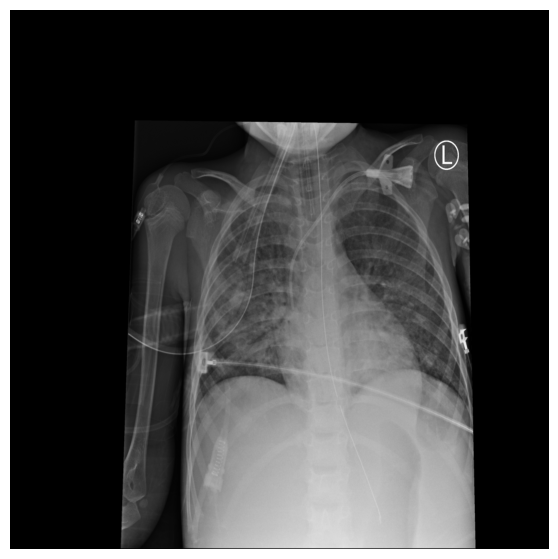

Top 2 image


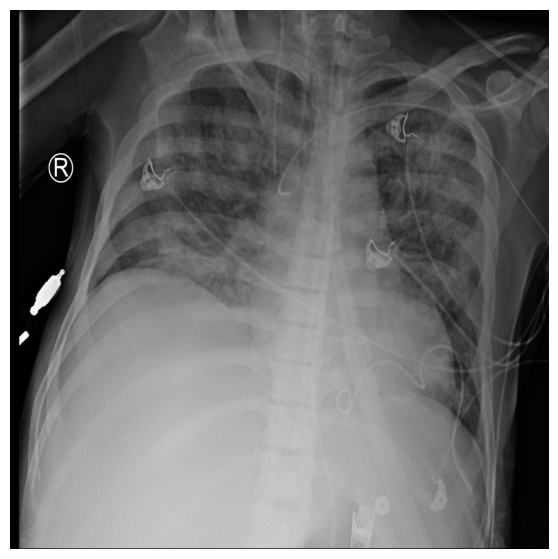

Top 3 image


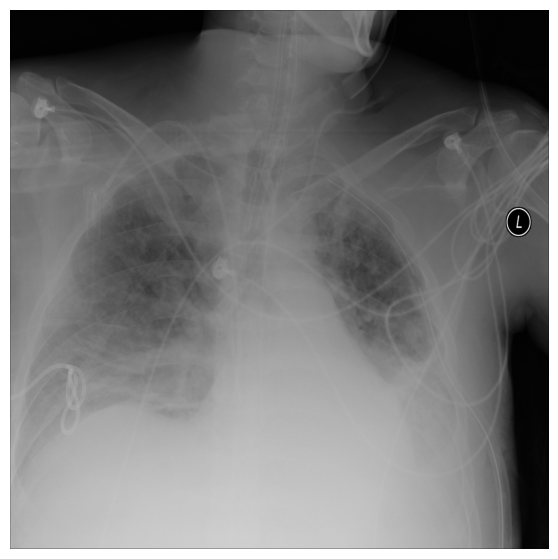

Top 4 image


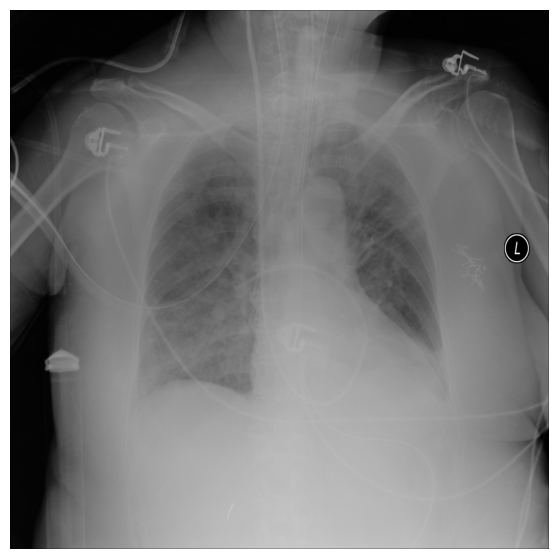

Top 5 image


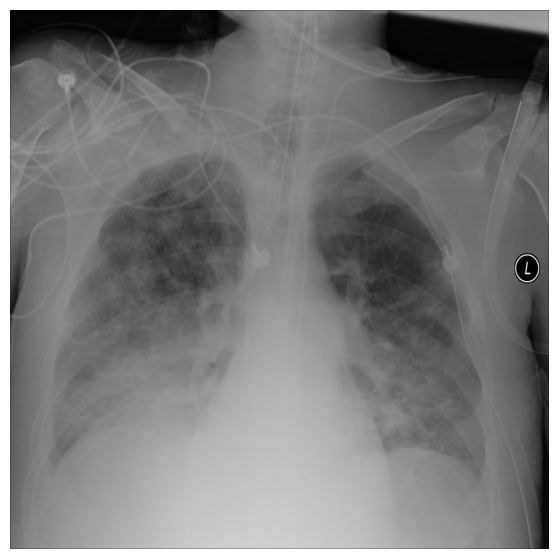

In [38]:
for i in range(5):
  dicom = pydicom.dcmread(similarity_df["dicom_file"].values[i])
  example = example_generator_lib.dicom_to_tfexample(dicom)
  print('Top %d image' % (i+1))
  show_dicom(example)